# 数据分析 part1

Vocaloid 音乐是由 vocaloid 虚拟歌姬演唱的音乐，因此参与的艺术家包括 p 主（即 producer，负责作曲和调教虚拟歌姬）、虚拟歌姬以及其他合作歌手。

以下将分 p 主和虚拟歌姬分别统计歌曲数量方面的数据。

In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
with open('../data/vocaloid_list.txt', 'r', encoding='utf-8') as f:
    vocaloids = f.read().split('\n')
if len(vocaloids[-1]) == 0:
    vocaloids.pop()
vocaloids_cnt = {x: 0 for x in vocaloids}

In [3]:
with open('../data/artist_info.json', 'r', encoding='utf-8') as f:
    artists = json.load(f)
with open('../data/song_info.json', 'r', encoding='utf-8') as f:
    songs = json.load(f)

In [4]:
producers = set()
for artist_id in list(artists):
    if artist_id not in vocaloids:
        producers.add(artist_id)
producers_cnt = {x: 0 for x in producers}

In [5]:
for song in songs.values():
    for artist in song['artist']:
        artist_id = artist['id']
        if artist_id in vocaloids:
            vocaloids_cnt[artist_id] += 1
        elif artist_id in producers:
            producers_cnt[artist_id] += 1

In [6]:
vocaloids_ranking = sorted(vocaloids_cnt.items(), key=lambda x: x[1])[::-1]
vocaloids_ranking = [(artists[x[0]]['name'], x[1]) for x in vocaloids_ranking]
vocaloids_ranking

[('初音ミク', 960),
 ('GUMI', 198),
 ('鏡音リン', 178),
 ('鏡音レン', 119),
 ('v flower', 91),
 ('巡音ルカ', 79),
 ('重音テト', 65),
 ('IA', 64),
 ('可不', 63),
 ('KAITO', 57),
 ('音街ウナ', 40),
 ('MEIKO', 34),
 ('歌愛ユキ', 26),
 ('結月ゆかり', 17),
 ('神威がくぽ', 15),
 ('夏色花梨', 10),
 ('裏命', 8),
 ('琴葉茜・葵', 8),
 ('花隈千冬', 8),
 ('小春六花', 8),
 ('MAYU', 7),
 ('星界', 7),
 ('鳴花ミコト', 6),
 ('鳴花ヒメ', 6),
 ('知声', 5),
 ('足立レイ', 5),
 ('ずんだもん', 5),
 ('闇音レンリ', 4),
 ('VY1', 4),
 ('猫村いろは', 4),
 ('ONE', 3),
 ('ナースロボ＿タイプＴ', 3),
 ('弦巻マキ', 3),
 ('ci flower', 3),
 ('miki', 3),
 ('心华', 2),
 ('宮舞モカ', 2),
 ('AiSuu', 2),
 ('Fukase', 2),
 ('Lily', 2),
 ('りむる', 2),
 ('夢ノ結唱 POPY', 2),
 ('氷山キヨテル', 1),
 ('夢ノ結唱 ROSE', 1),
 ('VOCALOID', 1),
 ('亞北ネル', 1),
 ('#kzn', 1),
 ('ゲキヤク', 1),
 ('紲星あかり', 1),
 ('雪歌ユフ', 1),
 ('LUMi', 1),
 ('東北ずん子', 1),
 ('琴葉葵', 1),
 ('琴葉茜', 1),
 ('名取さな', 1),
 ('绮萱', 1),
 ('羽累', 1)]

In [7]:
producers_ranking = sorted(producers_cnt.items(), key=lambda x: x[1])[::-1]
producers_ranking = [(artists[x[0]]['name'], x[1]) for x in producers_ranking]
producers_ranking

[('DECO*27', 65),
 ('ピノキオピー', 63),
 ('MARETU', 33),
 ('ナユタン星人', 31),
 ('MIMI', 30),
 ('かいりきベア', 29),
 ('じん', 28),
 ('みきとP', 25),
 ('タカオカミズキ', 24),
 ('Neru', 24),
 ('40mP', 24),
 ('sasakure.UK', 23),
 ('Orangestar', 23),
 ('Mitchie M', 22),
 ('いよわ', 21),
 ('wotaku', 21),
 ('n-buna', 20),
 ('煮ル果実', 20),
 ('Giga', 19),
 ('はるまきごはん', 19),
 ('ぬゆり', 16),
 ('ナナホシ管弦楽団', 16),
 ('一二三', 16),
 ('すりぃ', 16),
 ('cosMo@暴走P', 16),
 ('Chinozo', 16),
 ('稲葉曇', 16),
 ('和田たけあき', 15),
 ('れるりり', 15),
 ('柊キライ', 15),
 ('r-906', 14),
 ('米津玄師', 14),
 ('koyori', 14),
 ('GYARI', 14),
 ('須田景凪', 14),
 ('kanaria', 14),
 ('ツミキ', 13),
 ('柊マグネタイト', 13),
 ('すこっぷ', 13),
 ('まらしぃ', 13),
 ('トーマ', 12),
 ('とあ', 12),
 ('wowaka', 12),
 ('きくお', 12),
 ('蜂屋ななし', 11),
 ('ユリイ・カノン', 11),
 ('KEMU VOXX', 11),
 ('西沢さんP', 11),
 ('Eve', 10),
 ('オワタP', 10),
 ('香椎モイミ', 10),
 ('Sohbana', 10),
 ('ユギカ', 10),
 ('黒うさP', 10),
 ('mothy', 10),
 ('てにをは', 10),
 ('椎名もた', 9),
 ('ジミーサムP', 9),
 ('Last Note.', 9),
 ('ゆうゆ', 9),
 ('OSTER project', 9),
 ('キノシタ'

In [14]:
# 解决中文/日文无法显示问题
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'STSong']
plt.rcParams['axes.unicode_minus'] = False

In [20]:
def show_ranking(ranking_list, X_name, title):
    df = pd.DataFrame(ranking_list, columns=[X_name, '歌曲数量'])

    plt.figure(figsize=(12, 6))

    # 创建柱状图
    bars = plt.bar(df[X_name], df['歌曲数量'], color='skyblue')

    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom')

    # 设置标题和标签
    plt.title(title, fontsize=16, pad=20)
    plt.xlabel(X_name, fontsize=12)
    plt.ylabel('歌曲数量', fontsize=12)
    plt.xticks(rotation=45, ha='right')  # 旋转x轴标签

    # 调整布局
    plt.tight_layout()
    plt.show()

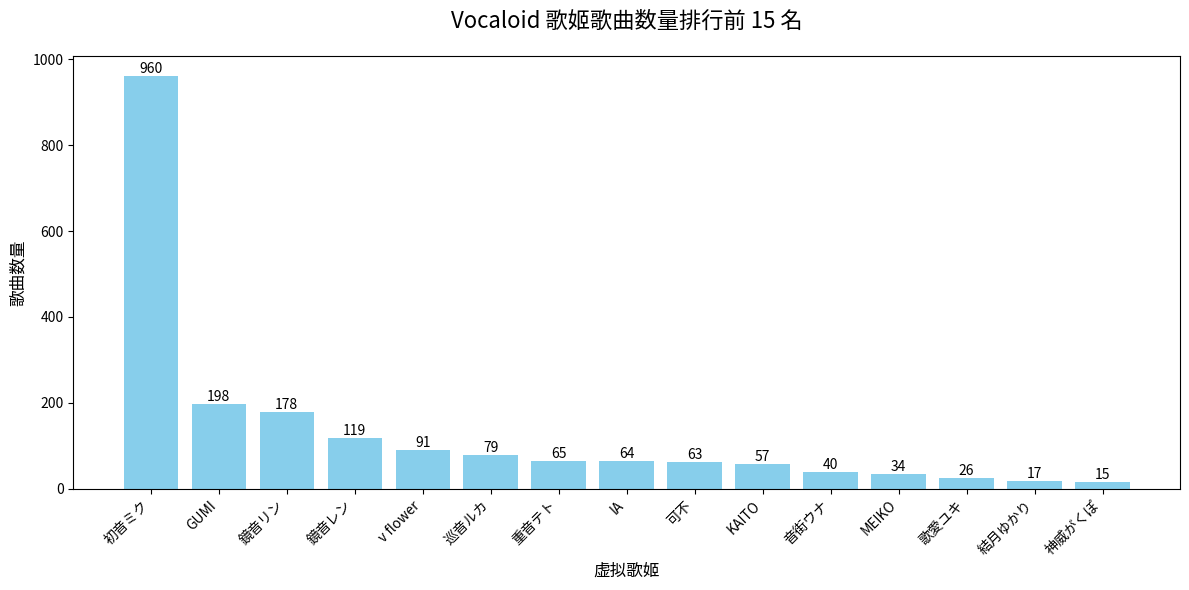

In [22]:
show_ranking(vocaloids_ranking[:15], '虚拟歌姬', 'Vocaloid 歌姬歌曲数量排行前 15 名')

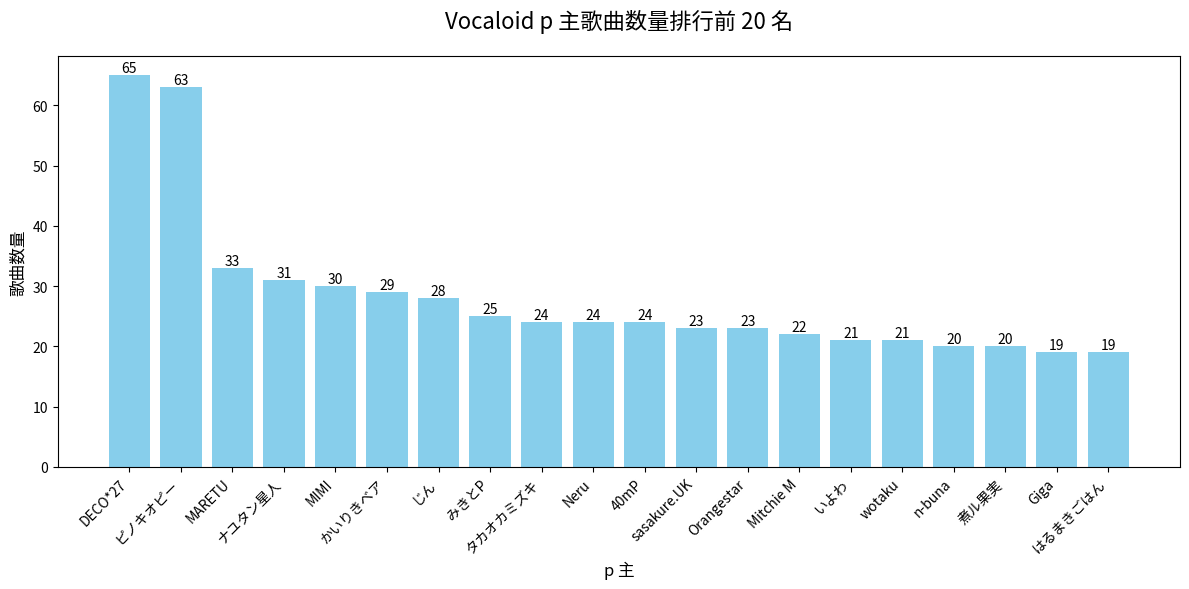

In [21]:
show_ranking(producers_ranking[:20], 'p 主', 'Vocaloid p 主歌曲数量排行前 20 名')

In [26]:
def show_wordcloud(ranking_list, title):
    freq_dict = dict(ranking_list)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        colormap='viridis'
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, pad=20)
    plt.show()

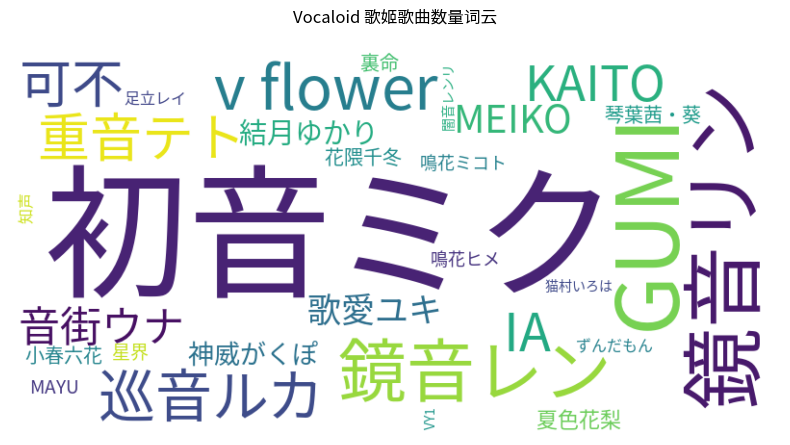

In [28]:
show_wordcloud(vocaloids_ranking[:30], 'Vocaloid 歌姬歌曲数量词云')

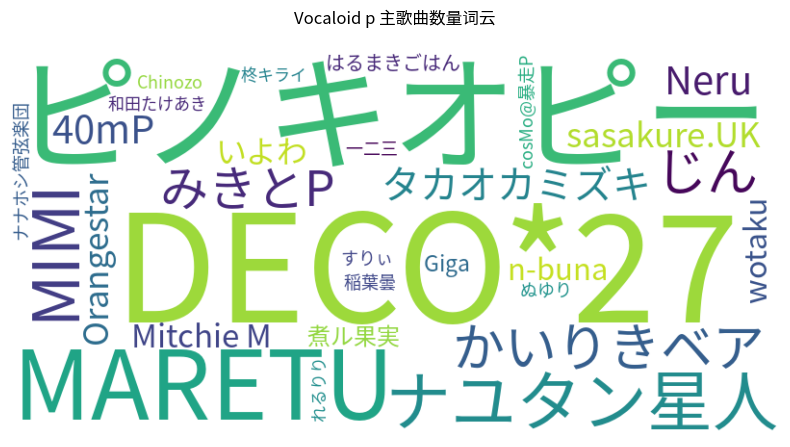

In [31]:
show_wordcloud(producers_ranking[:30], 'Vocaloid p 主歌曲数量词云')

## 结论

### 关于虚拟歌姬

- 初音ミク（Hatsune Miku）遥遥领先，达960首，其数量接近第二名GUMI（198首）的5倍，展示了其在Vocaloid生态中的压倒性核心地位。

- 紧随其后的是：GUMI 198首；镜音リン与レン（镜音双子）分别是 178 和 119 首；v flower、巡音ルカ等也有较高数量。

- 歌姬使用数量分布迅速下降，呈现典型的幂律分布（power-law）或“明星效应”：

    - 少数歌姬占据大部分歌曲；
    - 多数歌姬使用率远远低于头部。

### 关于 p 主

- 最活跃的 P 主是 DECO*27（65首）和ピノキオピー（63首），相对领先于其他 P 主，说明他们在 Vocaloid 领域中非常高产，可能也拥有广泛的受众和较高影响力。

- 第3名起歌曲数量快速下降，如：MARETU 33 首；ナユタン星人 31 首；MIMI 30 首。

- TOP20 P主的创作量集中在 20-65 首之间，形成了一个典型的“长尾分布”：

    - 前两位远超其他；
    - 而中间 P 主数量相对接近。

### 总结

- Vocaloid 生态具有高度中心化结构，核心人物和核心歌姬贡献了大部分内容。

- 但同时也存在丰富的中尾部创作者和歌姬，维持了整个生态的多样性与活力。